In [1]:
import pandas as pd
import numpy as np

In [3]:
#to read the file and check weather null values present inside it
dataset = pd.read_csv('/content/spotify_tracks.csv')
print(dataset.isnull().sum())

track_id            0
track_name          0
artist_name         0
album_name          0
release_year        0
genre               0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
key                 0
mode                0
time_signature      0
dtype: int64


In [4]:
dataset.describe()

,release_year,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2015.853400,23.599560,209976.955080,0.626921,0.658879,-7.438755,0.076370,0.275942,0.155218,0.181120,0.581443,116.258270,5.477220,0.619900,4.042800
std,6.178209,17.912623,44881.858907,0.207513,0.212950,4.305645,0.064989,0.257911,0.235443,0.096788,0.183994,23.706129,3.598764,0.485416,0.513939
min,2000.000000,-5.000000,90000.000000,0.000000,0.000000,-27.795904,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,3.000000
25%,2012.000000,11.000000,179812.250000,0.489439,0.539592,-9.802727,0.031339,0.075444,0.000000,0.112240,0.457651,100.238179,2.000000,0.000000,4.000000
50%,2017.000000,19.000000,209886.500000,0.651486,0.683479,-6.906656,0.062609,0.198993,0.064522,0.179683,0.581160,115.325911,5.000000,1.000000,4.000000
75%,2021.000000,31.000000,240023.750000,0.783254,0.812390,-4.425697,0.098898,0.412742,0.168282,0.247669,0.708097,130.455924,9.000000,1.000000,4.000000
max,2024.000000,100.000000,403583.000000,1.000000,1.000000,0.000000,0.368468,1.000000,1.000000,0.581942,1.000000,220.000000,11.000000,1.000000,7.000000


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          50000 non-null  object 
 1   track_name        50000 non-null  object 
 2   artist_name       50000 non-null  object 
 3   album_name        50000 non-null  object 
 4   release_year      50000 non-null  int64  
 5   genre             50000 non-null  object 
 6   popularity        50000 non-null  int64  
 7   duration_ms       50000 non-null  int64  
 8   explicit          50000 non-null  bool   
 9   danceability      50000 non-null  float64
 10  energy            50000 non-null  float64
 11  loudness          50000 non-null  float64
 12  speechiness       50000 non-null  float64
 13  acousticness      50000 non-null  float64
 14  instrumentalness  50000 non-null  float64
 15  liveness          50000 non-null  float64
 16  valence           50000 non-null  float6

In [6]:
#checking duplicate values
print(dataset.duplicated().sum())

0


In [9]:
#creating a new column with converting milliseconds to minutes
dataset['duration_min'] = dataset['duration_ms'] / 60000
dataset.head()

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature,duration_min
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,True,0.427723,...,0.050635,0.239506,0.181395,0.133053,0.431384,141.048735,6,0,4,3.150700
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,True,0.448634,...,0.000000,0.044463,0.097818,0.435949,0.559135,131.833287,0,1,5,3.113417
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,False,0.707923,...,0.144091,0.118380,0.000000,0.262254,0.516873,127.132954,2,1,5,2.030233
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,False,0.846237,...,0.006668,0.272844,0.000000,0.045332,0.667911,93.041715,0,1,6,3.600817
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,False,0.943720,...,0.057632,0.219752,0.098044,0.132083,0.772151,93.404975,7,1,4,2.602833


In [14]:
#creating a new column popularity level
dataset['popularity_level'] = np.where(dataset['popularity'] >= 80,'Popular Song', np.where(dataset['popularity'] >= 50,'Average Song', np.where(dataset['popularity'] >= 10,'Unpopular Song','Extremely Unpopular Song')))
dataset.head()

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,liveness,valence,tempo,key,mode,time_signature,duration_min,popularity_level,mood,tempo_level
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,True,0.427723,...,0.133053,0.431384,141.048735,6,0,4,3.150700,Unpopular Song,Sad Song,High Tempo
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,True,0.448634,...,0.435949,0.559135,131.833287,0,1,5,3.113417,Unpopular Song,Sad Song,Medium Tempo
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,False,0.707923,...,0.262254,0.516873,127.132954,2,1,5,2.030233,Unpopular Song,Sad Song,Medium Tempo
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,False,0.846237,...,0.045332,0.667911,93.041715,0,1,6,3.600817,Unpopular Song,Happy Song,Slow Tempo
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,False,0.943720,...,0.132083,0.772151,93.404975,7,1,4,2.602833,Unpopular Song,Happy Song,Slow Tempo


In [15]:
#creating a new column mood
dataset['mood'] = np.where(dataset['valence'] > 0.6, 'Happy Song','Sad Song')
dataset.head()

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,liveness,valence,tempo,key,mode,time_signature,duration_min,popularity_level,mood,tempo_level
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,True,0.427723,...,0.133053,0.431384,141.048735,6,0,4,3.150700,Unpopular Song,Sad Song,High Tempo
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,True,0.448634,...,0.435949,0.559135,131.833287,0,1,5,3.113417,Unpopular Song,Sad Song,Medium Tempo
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,False,0.707923,...,0.262254,0.516873,127.132954,2,1,5,2.030233,Unpopular Song,Sad Song,Medium Tempo
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,False,0.846237,...,0.045332,0.667911,93.041715,0,1,6,3.600817,Unpopular Song,Happy Song,Slow Tempo
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,False,0.943720,...,0.132083,0.772151,93.404975,7,1,4,2.602833,Unpopular Song,Happy Song,Slow Tempo


In [16]:
#creating new column tempo level
dataset['tempo_level'] = pd.cut(dataset['tempo'],bins = [0,100,140,300],labels =['Slow Tempo','Medium Tempo','High Tempo'])
dataset.head()

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,liveness,valence,tempo,key,mode,time_signature,duration_min,popularity_level,mood,tempo_level
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,True,0.427723,...,0.133053,0.431384,141.048735,6,0,4,3.150700,Unpopular Song,Sad Song,High Tempo
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,True,0.448634,...,0.435949,0.559135,131.833287,0,1,5,3.113417,Unpopular Song,Sad Song,Medium Tempo
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,False,0.707923,...,0.262254,0.516873,127.132954,2,1,5,2.030233,Unpopular Song,Sad Song,Medium Tempo
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,False,0.846237,...,0.045332,0.667911,93.041715,0,1,6,3.600817,Unpopular Song,Happy Song,Slow Tempo
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,False,0.943720,...,0.132083,0.772151,93.404975,7,1,4,2.602833,Unpopular Song,Happy Song,Slow Tempo


In [17]:
#creating new column decade
dataset['decade'] = (dataset['release_year'] // 10) * 10
dataset.head()

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,valence,tempo,key,mode,time_signature,duration_min,popularity_level,mood,tempo_level,decade
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,True,0.427723,...,0.431384,141.048735,6,0,4,3.150700,Unpopular Song,Sad Song,High Tempo,2020
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,True,0.448634,...,0.559135,131.833287,0,1,5,3.113417,Unpopular Song,Sad Song,Medium Tempo,2010
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,False,0.707923,...,0.516873,127.132954,2,1,5,2.030233,Unpopular Song,Sad Song,Medium Tempo,2020
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,False,0.846237,...,0.667911,93.041715,0,1,6,3.600817,Unpopular Song,Happy Song,Slow Tempo,2020
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,False,0.943720,...,0.772151,93.404975,7,1,4,2.602833,Unpopular Song,Happy Song,Slow Tempo,2010


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

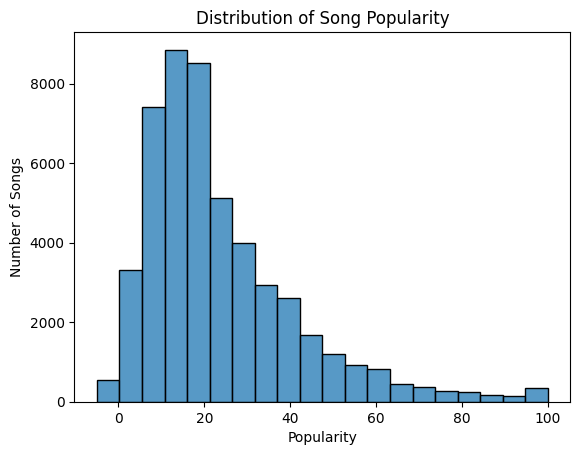

In [19]:
#showing number of song popular
sns.histplot(dataset['popularity'], bins=20)
plt.ylabel('Number of Songs')
plt.xlabel('Popularity')
plt.title('Distribution of Song Popularity')
plt.show()

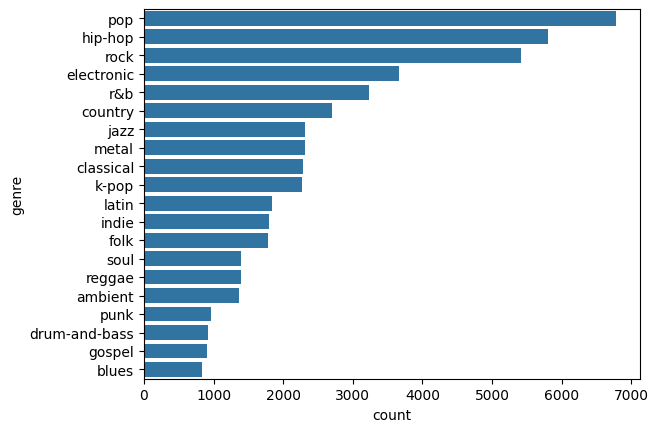

In [20]:
#count genre
sns.countplot(y=dataset['genre'], order=dataset['genre'].value_counts().index)
plt.show()

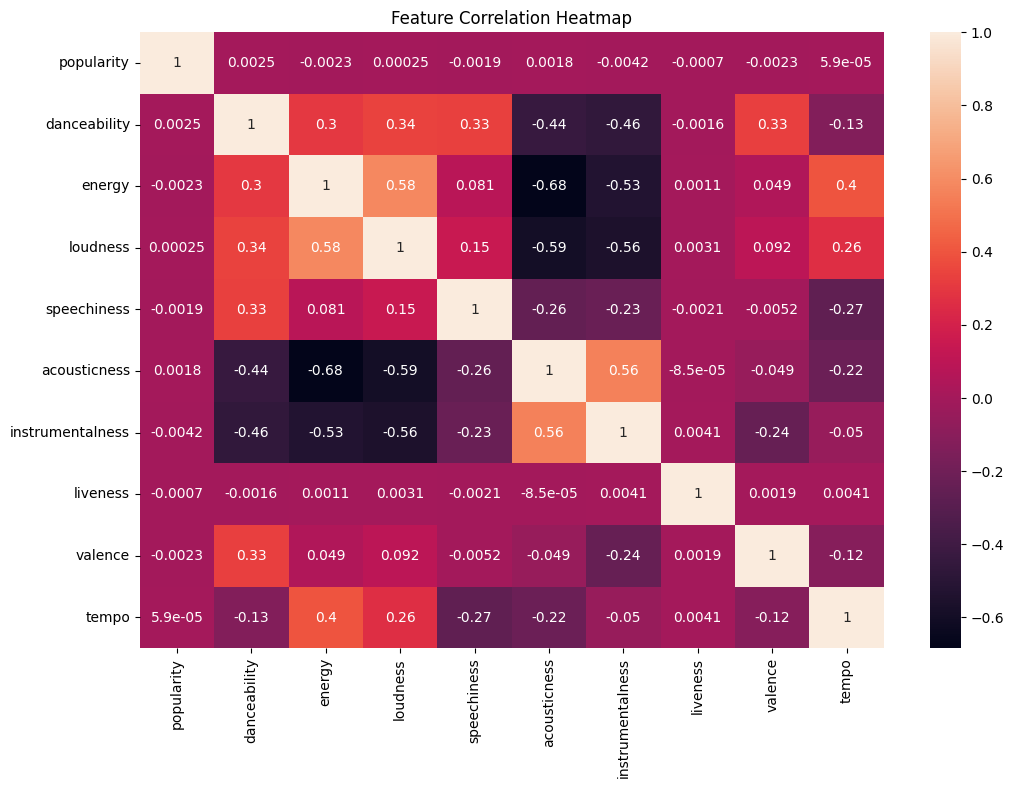

In [21]:
#heatmap with audio features vs popularity
corr = dataset[['popularity',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo']].corr()
plt.figure(figsize=(12,8))
plt.title("Feature Correlation Heatmap")
sns.heatmap(corr, annot=True)
plt.show()

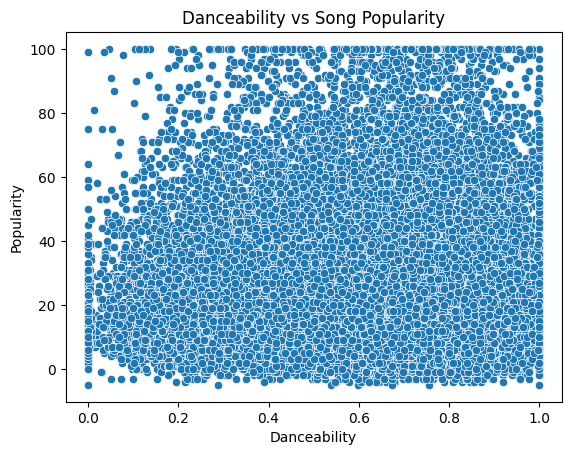

In [22]:
#danceability vs song popular
sns.scatterplot(data=dataset, x='danceability', y='popularity')
plt.title("Danceability vs Song Popularity")
plt.xlabel("Danceability")
plt.ylabel("Popularity")
plt.show()

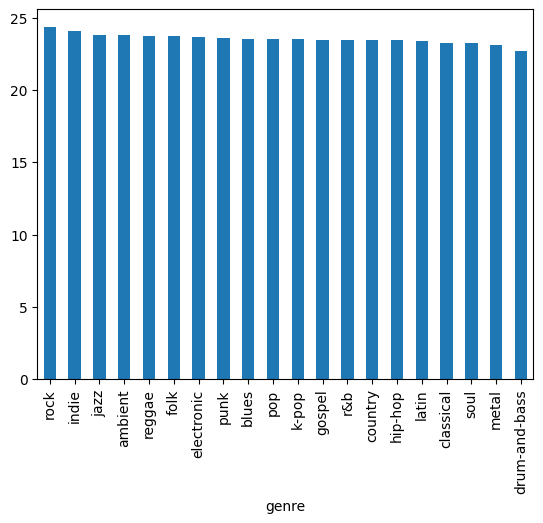

In [23]:
#show popular genre
dataset.groupby('genre')['popularity'].mean().sort_values(ascending=False).plot(kind='bar')
plt.show()

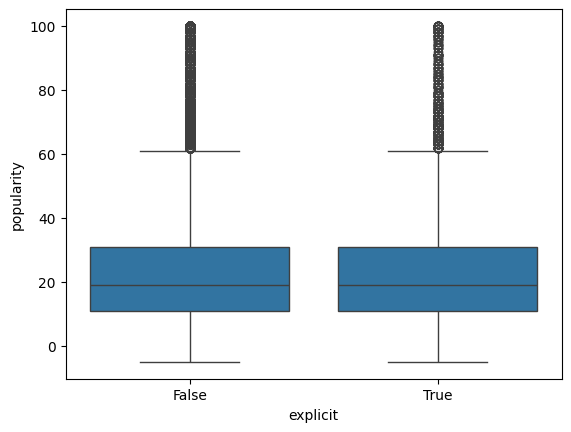

In [24]:
#boxplot- explicit with popularity
sns.boxplot(data = dataset, x = 'explicit', y = 'popularity')
plt.show()

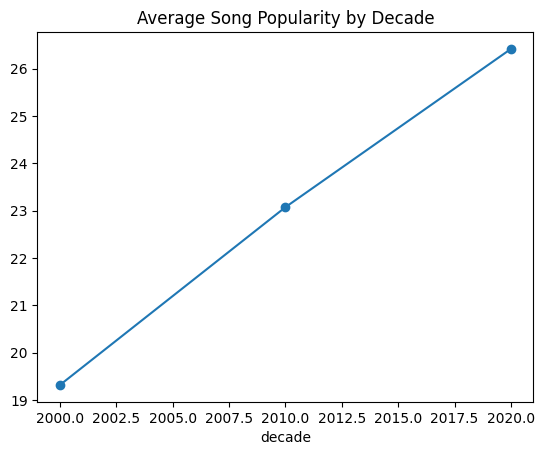

In [25]:
#popular songs with decades
dataset.groupby('decade')['popularity'].mean().plot(kind = 'line', marker = 'o')
plt.title("Average Song Popularity by Decade")
plt.show()

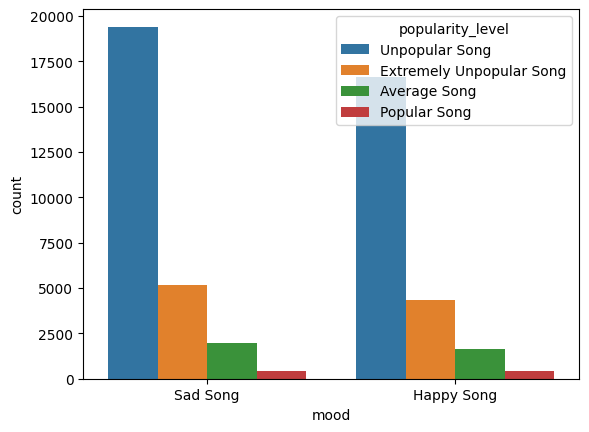

In [26]:
#show songs with popularity level
sns.countplot(x='mood', hue='popularity_level', data=dataset)
plt.show()

In [28]:
from google.colab import files
file_name = 'spotify_tracks_cleaned.csv'
dataset.to_csv('spotify_tracks_cleaned.csv', index=False)
files.download('spotify_tracks_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>